Przykład implementacji podstawowej sieci GAN (Generative Adversarial Network) w PyTorch do generowania obrazów cyfr.

In [5]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import torchvision

In [7]:
# Parametry modelu
latent_dim = 100  # Wymiar przestrzeni latentnej (wejście dla generatora)
image_dim = 28 * 28  # Rozmiar obrazów (28x28)
batch_size = 64
num_epochs = 50
lr = 0.0002  # Szybkość uczenia

In [9]:
# Generator
class Generator(nn.Module):
    def __init__(self, latent_dim, image_dim):
        super(Generator, self).__init__()
        self.model = nn.Sequential(
            nn.Linear(latent_dim, 128),
            nn.ReLU(),
            nn.Linear(128, 256),
            nn.ReLU(),
            nn.Linear(256, 512),
            nn.ReLU(),
            nn.Linear(512, image_dim),
            # [Kluczowe]: Tanh jest lepszy niż Sigmoid dla generatorów w GAN, 
            # daje mocniejsze i bardziej symetryczne gradienty.
            nn.Tanh()  # Wyjście w zakresie [-1, 1]
        )
    
    def forward(self, z):
        return self.model(z)

# Dyskryminator
class Discriminator(nn.Module):
    def __init__(self, image_dim):
        super(Discriminator, self).__init__()
        self.model = nn.Sequential(
            nn.Linear(image_dim, 512),
            # [Kluczowe]: LeakyReLU pozwala gradientom "przepływać" wstecz 
            # nawet przy ujemnych wartościach. Zapobiega "martwym neuronom".
            nn.LeakyReLU(0.2), 
            nn.Linear(512, 256),
            nn.LeakyReLU(0.2),
            nn.Linear(256, 1),
            # [Kluczowe]: Sprowadza wynik do klasycznego prawdopodobieństwa: 
            # 1 = prawdziwe zdjęcie, 0 = podróbka z generatora.
            nn.Sigmoid()  
        )
    
    def forward(self, x):
        return self.model(x)

In [11]:
# Przygotowanie danych MNIST
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize([0.5], [0.5])  # Normalizacja do zakresu [-1, 1]
])

dataset = datasets.MNIST(root='./data', train=True, transform=transform, download=True)
dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True)

In [13]:
# Inicjalizacja modelu
generator = Generator(latent_dim, image_dim)
discriminator = Discriminator(image_dim)

In [15]:
# Optymalizatory
optimizer_g = optim.Adam(generator.parameters(), lr=lr)
optimizer_d = optim.Adam(discriminator.parameters(), lr=lr)

In [17]:
# Funkcja straty
criterion = nn.BCELoss()

Epoch [1/50] | Loss D: 0.2700 | Loss G: 5.1512
Epoch [2/50] | Loss D: 0.6735 | Loss G: 2.3807
Epoch [3/50] | Loss D: 0.4092 | Loss G: 2.3937
Epoch [4/50] | Loss D: 0.3202 | Loss G: 3.2710
Epoch [5/50] | Loss D: 0.4813 | Loss G: 6.0910
Epoch [6/50] | Loss D: 0.5278 | Loss G: 5.1127
Epoch [7/50] | Loss D: 0.4711 | Loss G: 3.2933
Epoch [8/50] | Loss D: 0.1372 | Loss G: 5.4248
Epoch [9/50] | Loss D: 0.0775 | Loss G: 4.2282
Epoch [10/50] | Loss D: 0.1415 | Loss G: 4.8445


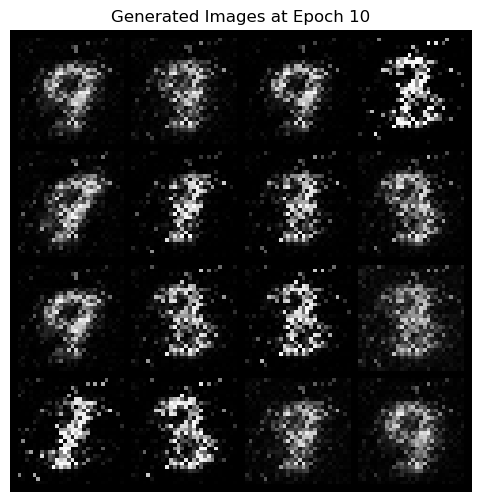

Epoch [11/50] | Loss D: 0.3094 | Loss G: 3.6344
Epoch [12/50] | Loss D: 0.2846 | Loss G: 4.2277
Epoch [13/50] | Loss D: 0.3714 | Loss G: 3.7923
Epoch [14/50] | Loss D: 0.2202 | Loss G: 4.1798
Epoch [15/50] | Loss D: 0.2925 | Loss G: 3.3497
Epoch [16/50] | Loss D: 0.4334 | Loss G: 5.0723
Epoch [17/50] | Loss D: 0.3788 | Loss G: 3.6411
Epoch [18/50] | Loss D: 0.3816 | Loss G: 2.5946
Epoch [19/50] | Loss D: 0.3601 | Loss G: 3.5389
Epoch [20/50] | Loss D: 0.3491 | Loss G: 6.0598


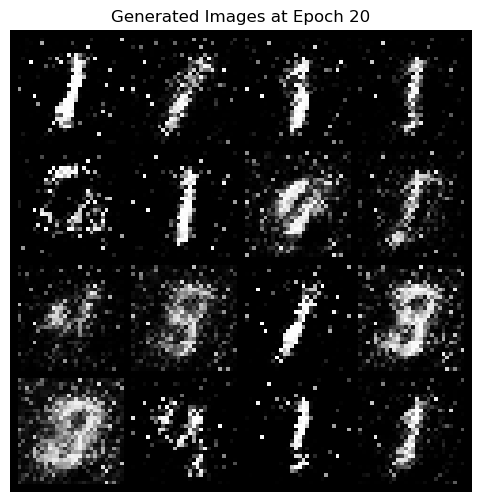

Epoch [21/50] | Loss D: 0.2423 | Loss G: 4.3197
Epoch [22/50] | Loss D: 0.3931 | Loss G: 4.0878
Epoch [23/50] | Loss D: 0.5902 | Loss G: 2.6289
Epoch [24/50] | Loss D: 0.3946 | Loss G: 3.5024
Epoch [25/50] | Loss D: 0.8946 | Loss G: 3.1110
Epoch [26/50] | Loss D: 0.4065 | Loss G: 1.7701
Epoch [27/50] | Loss D: 0.4318 | Loss G: 3.2075
Epoch [28/50] | Loss D: 0.8269 | Loss G: 2.8585
Epoch [29/50] | Loss D: 0.3904 | Loss G: 3.1661
Epoch [30/50] | Loss D: 0.6068 | Loss G: 2.8644


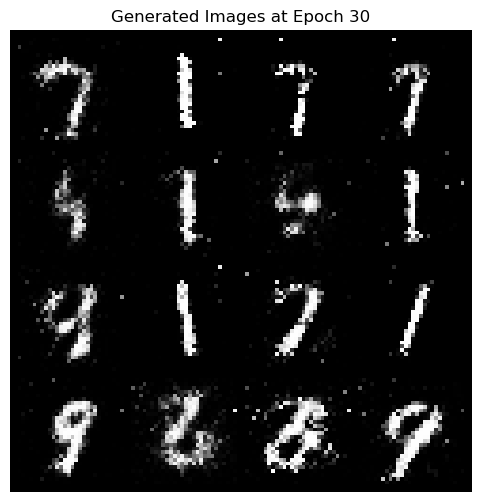

Epoch [31/50] | Loss D: 0.6481 | Loss G: 2.8435
Epoch [32/50] | Loss D: 0.5253 | Loss G: 3.3069
Epoch [33/50] | Loss D: 0.4754 | Loss G: 2.6568
Epoch [34/50] | Loss D: 0.5106 | Loss G: 2.2395
Epoch [35/50] | Loss D: 0.6850 | Loss G: 2.7457
Epoch [36/50] | Loss D: 0.3529 | Loss G: 3.3137
Epoch [37/50] | Loss D: 0.7628 | Loss G: 2.2166
Epoch [38/50] | Loss D: 0.4585 | Loss G: 2.9048
Epoch [39/50] | Loss D: 0.7414 | Loss G: 2.1474
Epoch [40/50] | Loss D: 0.9549 | Loss G: 1.5080


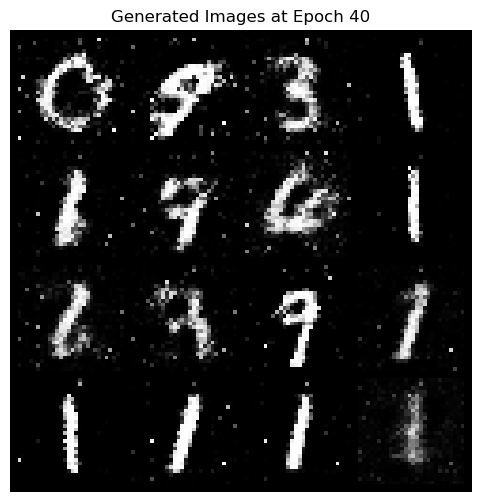

Epoch [41/50] | Loss D: 1.0404 | Loss G: 1.7448
Epoch [42/50] | Loss D: 0.4572 | Loss G: 2.3649
Epoch [43/50] | Loss D: 0.7579 | Loss G: 1.8222
Epoch [44/50] | Loss D: 0.6163 | Loss G: 2.2207
Epoch [45/50] | Loss D: 0.6474 | Loss G: 1.7366
Epoch [46/50] | Loss D: 0.8247 | Loss G: 1.6730
Epoch [47/50] | Loss D: 0.9650 | Loss G: 1.7200
Epoch [48/50] | Loss D: 0.9722 | Loss G: 1.7536
Epoch [49/50] | Loss D: 0.8090 | Loss G: 1.7616
Epoch [50/50] | Loss D: 0.4541 | Loss G: 2.3579


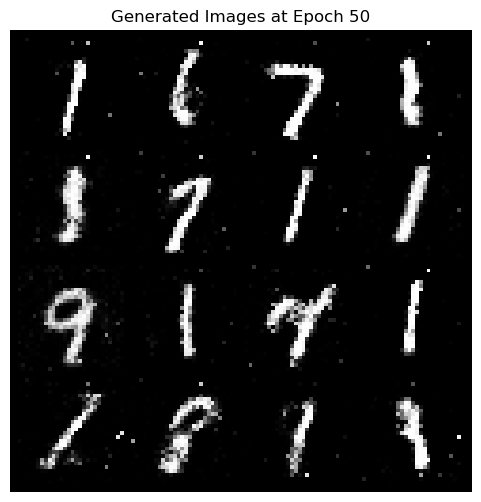

In [19]:
# Trening GAN
for epoch in range(num_epochs):
    for real_images, _ in dataloader:
        
        real_images = real_images.view(-1, image_dim).to(torch.float32)
        batch_size = real_images.size(0)
        
        # Generowanie etykiet: Prawda to 1, Fałsz to 0.
        real_labels = torch.ones(batch_size, 1)
        fake_labels = torch.zeros(batch_size, 1)
        
        # ==========================================
        # 1. TRENING DYSKRYMINATORA (Eksperta)
        # ==========================================
        optimizer_d.zero_grad()
        
        # Krok 1a: Uczy się rozpoznawać PRAWDĘ
        outputs_real = discriminator(real_images)
        loss_real = criterion(outputs_real, real_labels)
        
        # Krok 1b: Uczy się rozpoznawać FAŁSZ
        z = torch.randn(batch_size, latent_dim)
        fake_images = generator(z)
        
        # Używamy .detach()! 
        # Odczepiamy wygenerowane obrazy od grafu obliczeniowego Generatora.
        # Dyskryminator ma się uczyć tylko na własnych błędach. Gdybyśmy nie dali .detach(),
        # PyTorch próbowałby puścić gradienty wstecz aż do Generatora, co spowodowałoby błąd.
        outputs_fake = discriminator(fake_images.detach())
        loss_fake = criterion(outputs_fake, fake_labels)
        
        # Łączny błąd i aktualizacja wag Dyskryminatora
        loss_d = loss_real + loss_fake
        loss_d.backward()
        optimizer_d.step()
        
        # ==========================================
        # 2. TRENING GENERATORA (Fałszerza)
        # ==========================================
        optimizer_g.zero_grad()
        
        # Przepuszczamy fałszywe obrazy (tym razem bez .detach()!) ponownie przez Dyskryminator.
        outputs_fake = discriminator(fake_images)
        
        # Generator próbuje oszukać Dyskryminator!
        loss_g = criterion(outputs_fake, real_labels) 
        
        loss_g.backward()
        optimizer_g.step()
    
    # Wyświetlenie postępów
    print(f"Epoch [{epoch+1}/{num_epochs}] | Loss D: {loss_d.item():.4f} | Loss G: {loss_g.item():.4f}")

    # Generowanie obrazów co kilka epok
    if (epoch + 1) % 10 == 0:
        with torch.no_grad():
            z = torch.randn(16, latent_dim)
            # Przywracamy kształt obrazka (28x28 dla MNIST) do wyświetlenia
            generated_images = generator(z).view(-1, 1, 28, 28)
            
            # normalize=True świetnie radzi sobie z wyjściem funkcji Tanh (czyli [-1, 1])
            grid = torchvision.utils.make_grid(generated_images, nrow=4, normalize=True)
            
            plt.figure(figsize=(6, 6))
            plt.imshow(grid.permute(1, 2, 0).cpu().numpy())
            plt.title(f"Generated Images at Epoch {epoch+1}")
            plt.axis('off')
            plt.show()